<a href="https://colab.research.google.com/github/sileysa/Semester_5/blob/main/JS04/JS04_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Membaca Dataset

In [2]:
df = pd.read_csv('insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Melihat Ukuran Dataset

In [3]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 1338
Jumlah kolom : 7


# Informasi Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Statistik Dataset

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Mengecek Missing Value

In [6]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


# Identifikasi Variabel

In [7]:
print("Variabel dataset:")
print(df.columns.tolist())

Variabel dataset:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


# Visualisasi Umur vs Biaya Medis

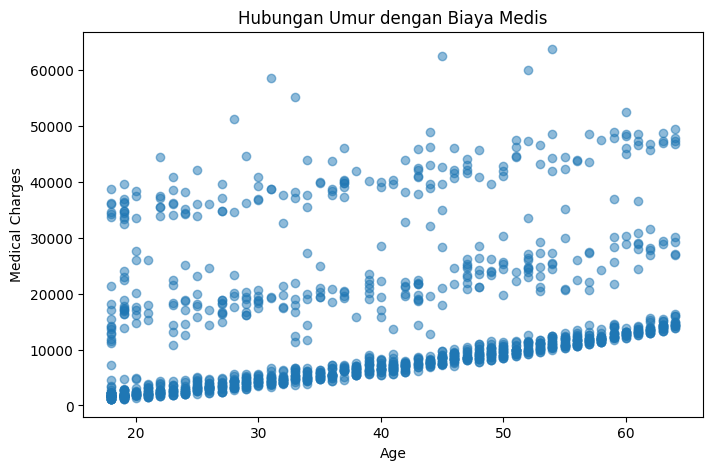

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['age'],
    df['charges'],
    alpha=0.5
)

plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.title('Hubungan Umur dengan Biaya Medis')

plt.show()

# Visualisasi BMI vs Biaya Medis

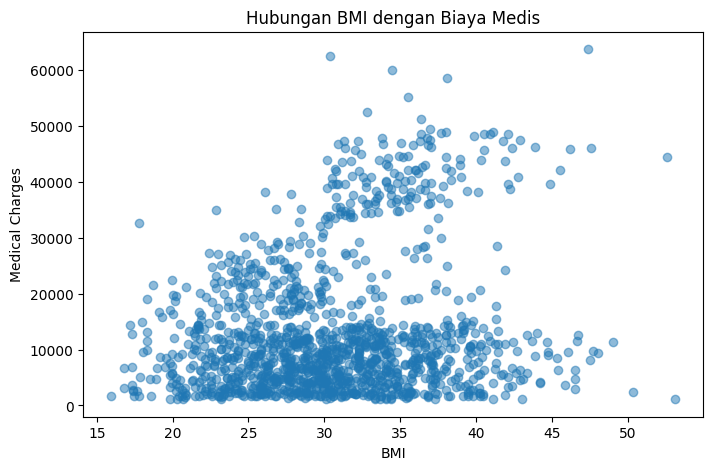

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['bmi'],
    df['charges'],
    alpha=0.5
)

plt.xlabel('BMI')
plt.ylabel('Medical Charges')
plt.title('Hubungan BMI dengan Biaya Medis')

plt.show()

# Visualisasi Status Merokok

<Figure size 800x500 with 0 Axes>

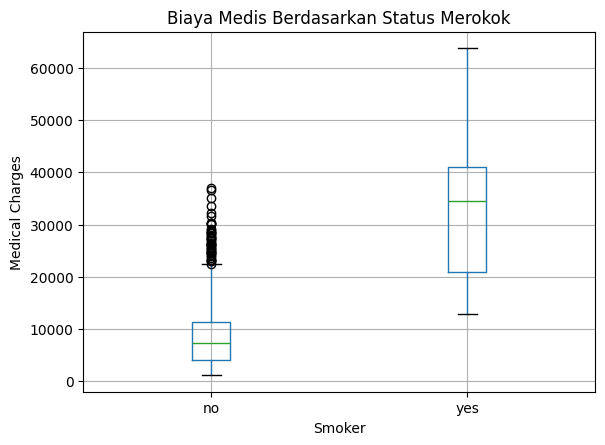

In [10]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column='charges',
    by='smoker'
)

plt.xlabel('Smoker')
plt.ylabel('Medical Charges')
plt.title('Biaya Medis Berdasarkan Status Merokok')

plt.suptitle('')

plt.show()

# Memisahkan Fitur dan Target

In [11]:
X = df.drop('charges', axis=1)
y = df['charges']

print("Fitur:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Fitur:
['age', 'sex', 'bmi', 'children', 'smoker', 'region']

Target:
charges


# Menentukan Kolom Numerik dan Kategorikal

In [12]:
numeric_features = [
    'age',
    'bmi',
    'children'
]

categorical_features = [
    'sex',
    'smoker',
    'region'
]

# Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Jumlah data training :", X_train.shape[0])
print("Jumlah data testing  :", X_test.shape[0])

Jumlah data training : 1070
Jumlah data testing  : 268


# Preprocessing

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

# Membuat Model Linear Regression

In [15]:
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Training Model

In [16]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regressor', LinearRegression())])

# Prediksi Linear Regression

In [17]:
y_pred_linear = linear_model.predict(X_test)

y_pred_linear[:10]

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084137, 16903.45028662,
        1092.43093614, 11218.34318352])

# Evaluasi Linear Regression

In [18]:
r2_linear = r2_score(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)

print("=== Multiple Linear Regression ===")
print(f"R-squared : {r2_linear:.4f}")
print(f"MSE       : {mse_linear:.2f}")
print(f"MAE       : {mae_linear:.2f}")

=== Multiple Linear Regression ===
R-squared : 0.7836
MSE       : 33596915.85
MAE       : 4181.19


# Actual vs Predicted

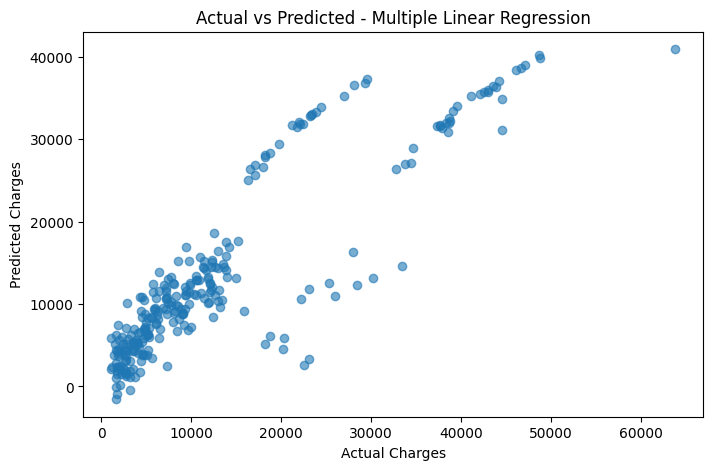

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.6
)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted - Multiple Linear Regression')

plt.show()

# Membuat Model SVR

In [ ]:
svr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR())
])

# Training SVR

In [21]:
svr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR())
])
svr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regressor', SVR())])

# Prediksi SVR

In [22]:
y_pred_svr = svr_model.predict(X_test)

y_pred_svr[:10]

array([9557.15344331, 9516.75135446, 9632.55223439, 9563.91635269,
       9551.13163867, 9550.2591831 , 9498.85806227, 9627.03625604,
       9526.80873976, 9576.46822955])

# Evaluasi SVR Default

In [23]:
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("=== SVR Default ===")
print(f"R-squared : {r2_svr:.4f}")
print(f"MSE       : {mse_svr:.2f}")
print(f"MAE       : {mae_svr:.2f}")

=== SVR Default ===
R-squared : -0.0706
MSE       : 166204282.70
MAE       : 8605.85


# Menentukan Parameter

In [24]:
param_grid = {
    'regressor__C': [1, 10, 100, 1000],
    'regressor__gamma': ['scale', 0.01, 0.1, 1],
    'regressor__epsilon': [0.01, 0.1, 0.2],
    'regressor__kernel': ['rbf', 'linear']
}

# GridSearchCV

In [25]:
grid_search = GridSearchCV(
    estimator=svr_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Menjalankan Tuning

In [26]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'region'])])),
                                       ('regressor', SVR())]),
             n_jobs=-1,
             param_grid={'regressor__C': [1, 10, 100, 1000],
                         'regressor__epsilon': [0.01, 0.1, 0.2],
                         'regressor__gamma': ['scale', 0.01, 0.1, 1],
                         'regressor__kernel': ['rbf', 'linear']},
             scoring='r2')

# Melihat Parameter Terbaik

In [27]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R²:")
print(grid_search.best_score_)

Best Parameters:
{'regressor__C': 1000, 'regressor__epsilon': 0.2, 'regressor__gamma': 'scale', 'regressor__kernel': 'linear'}

Best Cross-Validation R²:
0.6645792187314188


# Prediksi SVR Terbaik

In [28]:
best_svr = grid_search.best_estimator_

y_pred_svr_tuned = best_svr.predict(X_test)

# Evaluasi SVR Tuning

In [29]:
r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)
mse_svr_tuned = mean_squared_error(y_test, y_pred_svr_tuned)
mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)

print("=== SVR Tuned ===")
print(f"R-squared : {r2_svr_tuned:.4f}")
print(f"MSE       : {mse_svr_tuned:.2f}")
print(f"MAE       : {mae_svr_tuned:.2f}")

=== SVR Tuned ===
R-squared : 0.7532
MSE       : 38309139.31
MAE       : 3224.61


# Actual vs Predicted SVR

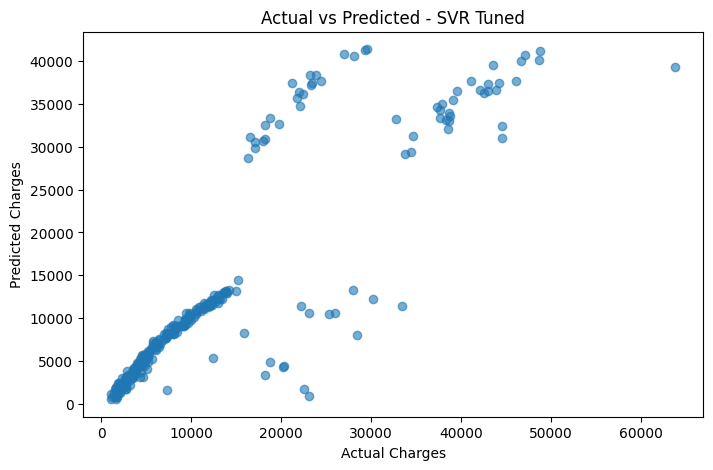

In [30]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_svr_tuned,
    alpha=0.6
)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted - SVR Tuned')

plt.show()

# Membandingkan Semua Model

In [31]:
results = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'SVR Default',
        'SVR Tuned'
    ],
    'R-Squared': [
        r2_linear,
        r2_svr,
        r2_svr_tuned
    ],
    'MSE': [
        mse_linear,
        mse_svr,
        mse_svr_tuned
    ],
    'MAE': [
        mae_linear,
        mae_svr,
        mae_svr_tuned
    ]
})

results

,Model,R-Squared,MSE,MAE
0,Multiple Linear Regression,0.783593,3.359692e+07,4181.194474
1,SVR Default,-0.070568,1.662043e+08,8605.845654
2,SVR Tuned,0.753240,3.830914e+07,3224.606950


# Grafik Perbandingan R^2

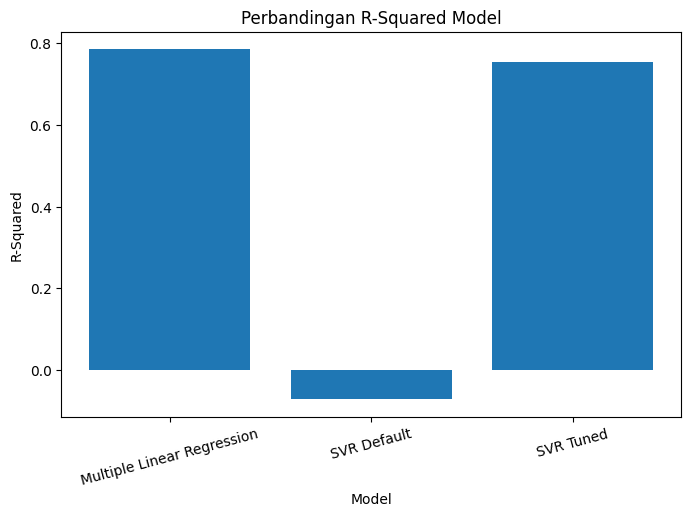

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    results['Model'],
    results['R-Squared']
)

plt.ylabel('R-Squared')
plt.xlabel('Model')
plt.title('Perbandingan R-Squared Model')
plt.xticks(rotation=15)

plt.show()

# Grafik Perbandingan MAE

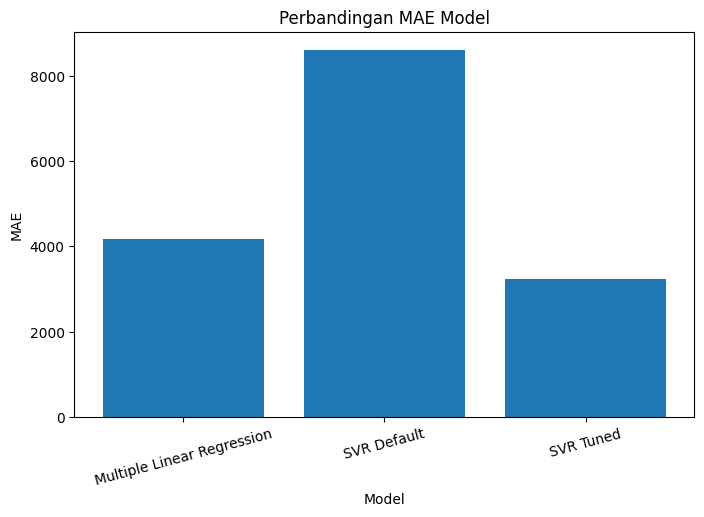

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(
    results['Model'],
    results['MAE']
)

plt.ylabel('MAE')
plt.xlabel('Model')
plt.title('Perbandingan MAE Model')
plt.xticks(rotation=15)

plt.show()

Berdasarkan percobaan yang telah dilakukan menggunakan Medical Cost Personal Dataset, variabel `age`, `sex`, `bmi`, `children`, `smoker`, dan `region` digunakan sebagai fitur, sedangkan `charges` digunakan sebagai variabel target.

Dataset dibagi menjadi data training sebesar 80% dan data testing sebesar 20%. Variabel kategorikal diproses menggunakan One-Hot Encoding, sedangkan variabel numerik dilakukan feature scaling menggunakan StandardScaler.

Pada Multiple Linear Regression diperoleh nilai R-squared sebesar 0,7836, MSE sebesar 33.596.915,85, dan MAE sebesar 4.181,19. Sementara itu, SVR dengan parameter default menghasilkan R-squared sebesar -0,0706, MSE sebesar 166.204.282,70, dan MAE sebesar 8.605,85.

Setelah dilakukan hyperparameter tuning menggunakan GridSearchCV, SVR memperoleh parameter terbaik yaitu C=1000, epsilon=0,2, gamma='scale', dan kernel='linear'. Hasil pengujian SVR setelah tuning memperoleh R-squared sebesar 0,7532, MSE sebesar 38.309.139,31, dan MAE sebesar 3.224,61.

Berdasarkan hasil evaluasi, Multiple Linear Regression memiliki nilai R-squared yang lebih tinggi dan MSE yang lebih rendah dibandingkan SVR setelah tuning pada data testing. Di sisi lain, SVR setelah tuning menghasilkan MAE yang lebih rendah. Perbedaan tersebut menunjukkan bahwa performa model dapat dilihat dari beberapa metrik dan tidak hanya berdasarkan satu metrik evaluasi.
